In [1]:
# Environment Paths & Directory Setup
import logging
import sys
from pathlib import Path

# Setup Google Drive mount if running in Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    has_colab = True
except Exception:
    has_colab = False

# Path Resolution
DEFAULT_COLAB_ROOT = Path("/content/drive/MyDrive/MPLADs")
ALT_COLAB_ROOT = Path("/content/drive/MYDrive/MPLADs")

if has_colab and DEFAULT_COLAB_ROOT.exists():
    PROJECT_ROOT = DEFAULT_COLAB_ROOT
elif has_colab and ALT_COLAB_ROOT.exists():
    PROJECT_ROOT = ALT_COLAB_ROOT
elif (Path.cwd() / "shared_preprocessing_artifacts").exists():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "shared_preprocessing_artifacts").exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

SHARED_ARTIFACT_DIR = PROJECT_ROOT / "shared_preprocessing_artifacts"
FEATURE1_ARTIFACT_DIR = PROJECT_ROOT / "feature1_artifacts"
FEATURE2_ARTIFACT_DIR = PROJECT_ROOT / "feature2_artifacts"
FEATURE3_ARTIFACT_DIR = PROJECT_ROOT / "feature3_artifacts"
FEATURE5_ARTIFACT_DIR = PROJECT_ROOT / "feature5_artifacts"
OUTPUT_DIR = PROJECT_ROOT / "feature7_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("mplads_feature7")

logger.info("Project Root: %s", PROJECT_ROOT)
logger.info("Shared Artifacts Dir: %s", SHARED_ARTIFACT_DIR)
logger.info("Feature 7 Output Dir: %s", OUTPUT_DIR)


Mounted at /content/drive


In [2]:
# Cell 2: Data Ingestion & Data Bus Resolution
import pandas as pd
import numpy as np

def read_artifact(dir_path: Path, name: str) -> pd.DataFrame:
    """Reads parquet artifact if available, falling back to CSV."""
    parquet_path = dir_path / f"{name}.parquet"
    csv_path = dir_path / f"{name}.csv"

    if parquet_path.exists():
        try:
            logger.info("Loading parquet: %s", parquet_path)
            return pd.read_parquet(parquet_path)
        except Exception as e:
            logger.warning("Failed loading parquet %s (%s). Falling back to CSV.", parquet_path, e)

    if csv_path.exists():
        logger.info("Loading CSV: %s", csv_path)
        return pd.read_csv(csv_path, low_memory=False)

    raise FileNotFoundError(f"Could not find {name}.parquet or {name}.csv in {dir_path}")

# 1. Load MP Master Dimension Table
dim_mp = read_artifact(SHARED_ARTIFACT_DIR, "dim_mp")
logger.info("Loaded dim_mp shape: %s", dim_mp.shape)

# 2. Resolve Work Data Bus Table (Handoff chain: F5 -> F2 -> F1 -> Shared)
fact_work = None
search_targets = [
    (SHARED_ARTIFACT_DIR, "fact_work_feature5"),
    (FEATURE5_ARTIFACT_DIR, "feature5_fact_work_vendor_risk"),
    (SHARED_ARTIFACT_DIR, "fact_work_feature2"),
    (SHARED_ARTIFACT_DIR, "fact_work_feature1"),
    (SHARED_ARTIFACT_DIR, "fact_work"),
]
for target_dir, target_name in search_targets:
    try:
        fact_work = read_artifact(target_dir, target_name)
        def _warn_upstream(source, df, expected):
            present = [c for c in expected if c in df.columns]
            missing = [c for c in expected if c not in df.columns]
            if not present:
                logger.warning('UPSTREAM DEGRADED: none of %s found (source=%s). Reading a lower bus tier.', expected, source)
            elif missing:
                logger.warning('UPSTREAM PARTIAL: missing %s (source=%s).', missing, source)
            else:
                logger.info('Upstream enrichment confirmed: %s (source=%s).', expected, source)
        _warn_upstream(target_name, fact_work, ['category_nlp', 'disbursement_risk_score', 'cost_risk_score', 'vendor_risk_score'])
        logger.info("Successfully loaded work data bus table from %s/%s. Shape: %s", target_dir.name, target_name, fact_work.shape)
        break
    except Exception:
        continue

for c in ['coverage_flag', 'disbursement_risk_score']:
    if c not in fact_work.columns:
        try:
            fw1 = read_artifact(SHARED_ARTIFACT_DIR, 'fact_work_feature1')
            if c in fw1.columns:
                fact_work = fact_work.merge(fw1[['work_key', c]], on='work_key', how='left')
        except: pass
if fact_work is None:
    raise FileNotFoundError("Could not locate any valid work fact table on the data bus.")

# 3. Load Expenditure Fact Table
fact_exp = read_artifact(SHARED_ARTIFACT_DIR, "fact_expenditure")
logger.info("Loaded fact_expenditure shape: %s", fact_exp.shape)

# 4. Load Vendor Master Risk Table
vendor_risk = None
try:
    vendor_risk = read_artifact(FEATURE5_ARTIFACT_DIR, "feature5_vendor_risk")
    logger.info("Loaded feature5_vendor_risk shape: %s", vendor_risk.shape)
except Exception as e:
    logger.warning("Could not load feature5_vendor_risk: %s. Using default vendor risk fallback.", e)


In [3]:
# MP-Level Sub-Score Aggregation (Exposure-Aware Financial Exposure Policy)
logger.info("--- Computing Exposure-Aware MP Sub-Scores ---")

fact_wv_bridge = read_artifact(SHARED_ARTIFACT_DIR, "fact_work_vendor")

# Feature 1 MP Exposure Sub-score
f1_linked = fact_work[
    fact_work["coverage_flag"].isin(["linked_final", "linked_tranche"]) &
    (fact_work["sanction_amount"] > 0) &
    fact_work["disbursement_risk_score"].notna()
].copy()
f1_linked["weighted_score"] = f1_linked["disbursement_risk_score"] * f1_linked["sanction_amount"]
g1 = f1_linked.groupby("mp_key").agg(num=("weighted_score", "sum"), den=("sanction_amount", "sum")).reset_index()
g1["s_f1_exposure"] = g1["num"] / g1["den"]
f1_mp_exp = g1[["mp_key", "s_f1_exposure"]]

f1_mp_count = f1_linked.groupby("mp_key")["disbursement_risk_score"].agg(s_f1_count_mean="mean", f1_linked_work_count="count").reset_index()
f1_tot_count = fact_work.groupby("mp_key")["work_key"].count().rename("f1_total_work_count").reset_index()

# Feature 2 MP Exposure Sub-score
f2_valid = fact_work[
    (~fact_work.get("cost_risk_tier", pd.Series("", index=fact_work.index)).isin(["Unknown / Invalid"])) &
    (fact_work["sanction_amount"] > 0) &
    fact_work["cost_risk_score"].notna()
].copy()
f2_valid["weighted_score"] = f2_valid["cost_risk_score"] * f2_valid["sanction_amount"]
g2 = f2_valid.groupby("mp_key").agg(num=("weighted_score", "sum"), den=("sanction_amount", "sum")).reset_index()
g2["s_f2_exposure"] = g2["num"] / g2["den"]
f2_mp_exp = g2[["mp_key", "s_f2_exposure"]]

f2_mp_count = f2_valid.groupby("mp_key")["cost_risk_score"].agg(s_f2_count_mean="mean", f2_valid_cost_count="count").reset_index()

# Feature 5 MP Exposure Sub-score from work-vendor bridge
wv_bridge_mp = fact_wv_bridge.merge(fact_work[["work_key", "mp_key"]], on="work_key", how="left")
wv_bridge_valid = wv_bridge_mp[wv_bridge_mp["vendor_risk_score"].notna() & (wv_bridge_mp["vendor_spend"] > 0)].copy()
wv_bridge_valid["weighted_score"] = wv_bridge_valid["vendor_risk_score"] * wv_bridge_valid["vendor_spend"]
g5 = wv_bridge_valid.groupby("mp_key").agg(num=("weighted_score", "sum"), den=("vendor_spend", "sum")).reset_index()
g5["s_f5_exposure"] = g5["num"] / g5["den"]
f5_mp_exp = g5[["mp_key", "s_f5_exposure"]]

f5_mp_count = wv_bridge_valid.groupby("mp_key")["vendor_risk_score"].agg(s_f5_count_mean="mean", f5_known_vendor_row_count="count").reset_index()
wv_bridge_mp["known_vendor_spend"] = np.where(wv_bridge_mp["vendor_risk_score"].notna(), wv_bridge_mp["vendor_spend"], 0.0)
vendor_cov = wv_bridge_mp.groupby("mp_key").agg(mp_known_vendor_spend=("known_vendor_spend", "sum"), mp_total_vendor_spend=("vendor_spend", "sum")).reset_index()
vendor_cov["f5_vendor_risk_coverage"] = vendor_cov["mp_known_vendor_spend"] / np.maximum(1.0, vendor_cov["mp_total_vendor_spend"])


# Merge into MP Master Scorecard
mp_df = dim_mp[["mp_key", "mp_name_clean", "house", "state", "state_key", "constituency", "allocated_amount"]].copy()
fact_work_bus = read_artifact(SHARED_ARTIFACT_DIR, "fact_work_feature5")
mp_sanct = (
    fact_work_bus.groupby("mp_key")["sanction_amount"].sum()
    .rename("total_sanctioned_amount").reset_index()
)
mp_df = mp_df.merge(mp_sanct, on="mp_key", how="left")
mp_df["allocation_utilization_pct"] = np.where(
    mp_df["allocated_amount"].notna() & (mp_df["allocated_amount"] > 0),
    mp_df["total_sanctioned_amount"].fillna(0.0) / mp_df["allocated_amount"],
    np.nan,
)
mp_df = mp_df.merge(f1_mp_exp, on="mp_key", how="left")
mp_df = mp_df.merge(f1_mp_count, on="mp_key", how="left")
mp_df = mp_df.merge(f1_tot_count, on="mp_key", how="left")
mp_df = mp_df.merge(f2_mp_exp, on="mp_key", how="left")
mp_df = mp_df.merge(f2_mp_count, on="mp_key", how="left")
mp_df = mp_df.merge(f5_mp_exp, on="mp_key", how="left")
mp_df = mp_df.merge(f5_mp_count, on="mp_key", how="left")
mp_df = mp_df.merge(vendor_cov[["mp_key", "f5_vendor_risk_coverage"]], on="mp_key", how="left")

mp_df["f1_coverage_rate"] = mp_df["f1_linked_work_count"].fillna(0) / np.maximum(1.0, mp_df["f1_total_work_count"].fillna(1.0))
mp_df["f2_valid_cost_rate"] = mp_df["f2_valid_cost_count"].fillna(0) / np.maximum(1.0, mp_df["f1_total_work_count"].fillna(1.0))
mp_df["f5_vendor_risk_coverage"] = mp_df["f5_vendor_risk_coverage"].fillna(0.0)

mp_df["s_f1"] = mp_df["s_f1_exposure"]
mp_df["s_f2"] = mp_df["s_f2_exposure"]
mp_df["s_f5"] = mp_df["s_f5_exposure"]

logger.info("Exposure-aware MP Base Scorecard prepared for %d MPs.", len(mp_df))






In [4]:
# Cell 4: Winsorization, Z-Score Standardization & Pairwise Correlation Diagnostic
logger.info("--- Performing Winsorization, Z-Score Standardization & Correlation Checks ---")

# 1. Outlier Winsorization at 1st and 99th Percentiles & Robust Z-Scores
for col in ["s_f1", "s_f2", "s_f5"]:
    valid_vals = mp_df[col].dropna()
    if not valid_vals.empty:
        p1, p99 = np.percentile(valid_vals, [1, 99])
        mu, std = valid_vals.mean(), valid_vals.std()
        mp_df[f"{col}_winsor"] = np.clip(mp_df[col], p1, p99)
        mp_df[f"z_{col}"] = np.where(mp_df[col].notna(), (mp_df[f"{col}_winsor"] - mu) / (std if std > 0 else 1.0), np.nan)
    else:
        mp_df[f"{col}_winsor"] = np.nan
        mp_df[f"z_{col}"] = np.nan

# 2. Pairwise Pearson Correlation Matrix R
corr_matrix = mp_df[["z_s_f1", "z_s_f2", "z_s_f5"]].corr().fillna(0.0)
print("--- Pairwise Pearson Correlation Matrix (R) ---")
print(corr_matrix)



--- Pairwise Pearson Correlation Matrix (R) ---
          z_s_f1   z_s_f2    z_s_f5
z_s_f1  1.000000  0.24175  0.333433
z_s_f2  0.241750  1.00000  0.394360
z_s_f5  0.333433  0.39436  1.000000


In [5]:
# Composite Risk Assembly & Removal of Null-to-Zero Bias
Z_SCORE_COLS = ["z_s_f1", "z_s_f2", "z_s_f5"]
N_DIMS = len(Z_SCORE_COLS)
z_cols = Z_SCORE_COLS
observed = mp_df[z_cols].notna()
mp_df["composite_observed_dimension_count"] = observed.sum(axis=1)

# Raw Composite Score calculated over observed sub-scores ONLY
mp_df["raw_composite_score"] = mp_df[z_cols].mean(axis=1, skipna=True)
mp_df.loc[mp_df["composite_observed_dimension_count"] == 0, "raw_composite_score"] = np.nan

mp_df["composite_data_quality_tier"] = np.select(
    [mp_df["composite_observed_dimension_count"] == N_DIMS, mp_df["composite_observed_dimension_count"].between(1, N_DIMS - 1)],
    ["Complete", "Partial"], default="Insufficient"
)

valid_raw = mp_df["raw_composite_score"].dropna()
c_min, c_max = valid_raw.min(), valid_raw.max()
mp_df["composite_risk_score"] = np.where(
    mp_df["raw_composite_score"].notna(),
    (mp_df["raw_composite_score"] - c_min) / (c_max - c_min) if c_max > c_min else 0.0,
    np.nan
)

mp_df["score_percentile"] = np.where(
    mp_df["composite_risk_score"].notna(),
    mp_df["composite_risk_score"].rank(pct=True) * 100.0,
    np.nan
)

# Calibrated Thresholds
CRITICAL_THRESH = 0.70
HIGH_THRESH = 0.50
MEDIUM_THRESH = 0.30

def assign_tier_calibrated(row):
    if row["composite_data_quality_tier"] == "Insufficient" or pd.isna(row["composite_risk_score"]):
        return "Unknown / Insufficient Data"
    score = row["composite_risk_score"]
    if score >= CRITICAL_THRESH: return "Critical"
    elif score >= HIGH_THRESH: return "High"
    elif score >= MEDIUM_THRESH: return "Medium"
    else: return "Low"

mp_df["composite_risk_tier"] = mp_df.apply(assign_tier_calibrated, axis=1)

print("--- Calibrated Percentile Risk Tier Distribution ---")
print(mp_df["composite_risk_tier"].value_counts(dropna=False))


--- Calibrated Percentile Risk Tier Distribution ---
composite_risk_tier
Unknown / Insufficient Data    230
Low                            194
Medium                         183
High                           117
Critical                        50
Name: count, dtype: int64


In [6]:
# Cell 6: ML Stretch Layer 1 - Data-Driven Risk Tier Clustering (K-Means & GMM)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import joblib

logger.info("--- Executing ML Stretch Layer 1: Data-Driven Risk Tier Clustering (K-Means & GMM) ---")

# Feature matrix for clustering: standardized sub-scores (impute NaN with neutral 0.0 mean)
X_subscores = mp_df[["z_s_f1", "z_s_f2", "z_s_f5"]].fillna(0.0).values

# Fit K-Means with K=4 (corresponding to 4 risk tiers)
n_clusters = min(4, len(mp_df))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
raw_clusters = kmeans.fit_predict(X_subscores)

# Sort clusters by mean composite_risk_score of members to map to canonical risk tiers
mp_df["temp_cluster"] = raw_clusters
cluster_order = mp_df.groupby("temp_cluster")["composite_risk_score"].mean().sort_values().index.tolist()

tier_names = ["Low", "Medium", "High", "Critical"]
tier_map = {cluster_order[i]: tier_names[min(i, len(tier_names) - 1)] for i in range(len(cluster_order))}
mp_df["mp_kmeans_tier"] = mp_df["temp_cluster"].map(tier_map)
mp_df.drop(columns=["temp_cluster"], inplace=True)

# Fit Gaussian Mixture Model (GMM) as probabilistic clustering baseline
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_subscores)
mp_df["gmm_max_prob"] = gmm.predict_proba(X_subscores).max(axis=1)

# Save K-Means Model Artifact
kmeans_model_path = OUTPUT_DIR / "feature7_kmeans_model.joblib"
joblib.dump({
    "kmeans_model": kmeans,
    "gmm_model": gmm,
    "cluster_tier_map": tier_map,
    "feature_cols": ["z_s_f1", "z_s_f2", "z_s_f5"]
}, kmeans_model_path)
logger.info("Exported K-Means/GMM clustering pipeline to %s", kmeans_model_path.name)

print("--- Data-Driven K-Means Risk Tier Distribution ---")
print(mp_df["mp_kmeans_tier"].value_counts())



--- Data-Driven K-Means Risk Tier Distribution ---
mp_kmeans_tier
Medium      407
Low         197
Critical    102
High         68
Name: count, dtype: int64


In [7]:
# Secondary ML layer: fit and apply only to MPs with all three observed
# dimensions. Partial MPs retain their observed baseline score and do not get
# a synthetic zero-risk dimension.
from sklearn.ensemble import IsolationForest

complete_mask = mp_df["composite_data_quality_tier"].eq("Complete") & mp_df[Z_SCORE_COLS].notna().all(axis=1)
X_complete = mp_df.loc[complete_mask, Z_SCORE_COLS].values
iforest = IsolationForest(n_estimators=100, contamination=0.03, random_state=42, n_jobs=-1)
iforest.fit(X_complete)
raw_if_scores = -iforest.score_samples(X_complete)
score_min, score_max = raw_if_scores.min(), raw_if_scores.max()
mp_df["mp_iforest_score"] = np.nan
mp_df.loc[complete_mask, "mp_iforest_score"] = (raw_if_scores - score_min) / (score_max - score_min) if score_max > score_min else 0.0

mp_df["ml_augmented_composite_risk_score"] = mp_df["composite_risk_score"]
mp_df.loc[complete_mask, "ml_augmented_composite_risk_score"] = np.clip(
    0.75 * mp_df.loc[complete_mask, "composite_risk_score"] +
    0.25 * mp_df.loc[complete_mask, "mp_iforest_score"], 0.0, 1.0
)

def assign_ml_tier(row):
    if row["composite_data_quality_tier"] == "Insufficient" or pd.isna(row["ml_augmented_composite_risk_score"]):
        return "Unknown / Insufficient Data"
    score = row["ml_augmented_composite_risk_score"]
    if score >= CRITICAL_THRESH: return "Critical"
    if score >= HIGH_THRESH: return "High"
    if score >= MEDIUM_THRESH: return "Medium"
    return "Low"

mp_df["ml_augmented_risk_tier"] = mp_df.apply(assign_ml_tier, axis=1)
iforest_model_path = OUTPUT_DIR / "feature7_isolation_forest.joblib"
joblib.dump({
    "model": iforest,
    "feature_cols": Z_SCORE_COLS,
    "complete_only": True,
    "score_min": float(score_min),
    "score_max": float(score_max)
}, iforest_model_path)



['/content/drive/MyDrive/MPLADs/feature7_artifacts/feature7_isolation_forest.joblib']

In [8]:
# Cell 8: Natural Language Audit Explanation Generator
def generate_mp_explanation(row: pd.Series) -> str:
    """Generates comprehensive natural language explanations incorporating baseline + ML anomaly signals."""
    tier = row["ml_augmented_risk_tier"]
    score = row["ml_augmented_composite_risk_score"]
    mp_name = row["mp_name_clean"] if pd.notna(row["mp_name_clean"]) else row["mp_key"]
    state = row["state"] if pd.notna(row["state"]) else "Unknown State"
    z_f1 = row["z_s_f1"] if pd.notna(row["z_s_f1"]) else 0.0
    z_f2 = row["z_s_f2"] if pd.notna(row["z_s_f2"]) else 0.0
    z_f5 = row["z_s_f5"] if pd.notna(row["z_s_f5"]) else 0.0
    if_score = row.get("mp_iforest_score", 0.0)
    if pd.isna(if_score):
        if_score = 0.0
    kmeans_tier = row.get("mp_kmeans_tier", "Unclustered")

    drivers = []
    if z_f1 >= 1.0:
        drivers.append(f"elevated fund disbursement shortfall (Z={z_f1:.2f})")
    if z_f2 >= 1.0:
        drivers.append(f"high sanction cost overruns relative to state peers (Z={z_f2:.2f})")
    if z_f5 >= 1.0:
        drivers.append(f"high spend concentration among top contractors (Z={z_f5:.2f})")
    if if_score >= 0.70:
        drivers.append(f"unusual multivariate sub-score combination detected by Isolation Forest (score: {if_score:.2f})")

    driver_str = "; ".join(drivers) if drivers else f"balanced sub-scores (Z_disb={z_f1:.2f}, Z_cost={z_f2:.2f}, Z_vend={z_f5:.2f})"

    if tier == "Critical":
        return f"CRITICAL COMPOSITE MP RISK (Score: {score:.2f}, Top 10%): MP '{mp_name}' ({state}) exhibits critical anomaly signals driven by {driver_str}. K-Means cluster tag: '{kmeans_tier}'."
    elif tier == "High":
        return f"HIGH COMPOSITE MP RISK (Score: {score:.2f}, Top 25%): MP '{mp_name}' ({state}) shows elevated risk driven by {driver_str}. K-Means cluster tag: '{kmeans_tier}'."
    elif tier == "Medium":
        return f"MODERATE COMPOSITE MP RISK (Score: {score:.2f}): MP '{mp_name}' ({state}) exhibits moderate risk indicators ({driver_str})."
    else:
        return f"LOW COMPOSITE MP RISK (Score: {score:.2f}): MP '{mp_name}' ({state}) shows standard baseline risk across all sub-score dimensions."

mp_df["composite_risk_explanation"] = mp_df.apply(generate_mp_explanation, axis=1)

print("--- Sample Critical MP Audit Explanations (Baseline + ML Signals) ---")
critical_samples = mp_df[mp_df["ml_augmented_risk_tier"] == "Critical"]["composite_risk_explanation"].head(5)
for i, exp in enumerate(critical_samples, 1):
    print(f"{i}. {exp}")



--- Sample Critical MP Audit Explanations (Baseline + ML Signals) ---
1. CRITICAL COMPOSITE MP RISK (Score: 0.75, Top 10%): MP 'ADHIKARI SOUMENDU' (West Bengal) exhibits critical anomaly signals driven by high sanction cost overruns relative to state peers (Z=1.42). K-Means cluster tag: 'Critical'.
2. CRITICAL COMPOSITE MP RISK (Score: 1.00, Top 10%): MP 'ALFRED KANNGAM S ARTHUR' (Manipur) exhibits critical anomaly signals driven by high sanction cost overruns relative to state peers (Z=2.44). K-Means cluster tag: 'Critical'.
3. CRITICAL COMPOSITE MP RISK (Score: 0.80, Top 10%): MP 'ANGOMCHA BIMOL AKOIJAM' (Manipur) exhibits critical anomaly signals driven by high sanction cost overruns relative to state peers (Z=1.63). K-Means cluster tag: 'Critical'.
4. CRITICAL COMPOSITE MP RISK (Score: 0.74, Top 10%): MP 'ANURAG SHARMA' (Uttar Pradesh) exhibits critical anomaly signals driven by high sanction cost overruns relative to state peers (Z=1.37). K-Means cluster tag: 'Critical'.
5. CRITIC

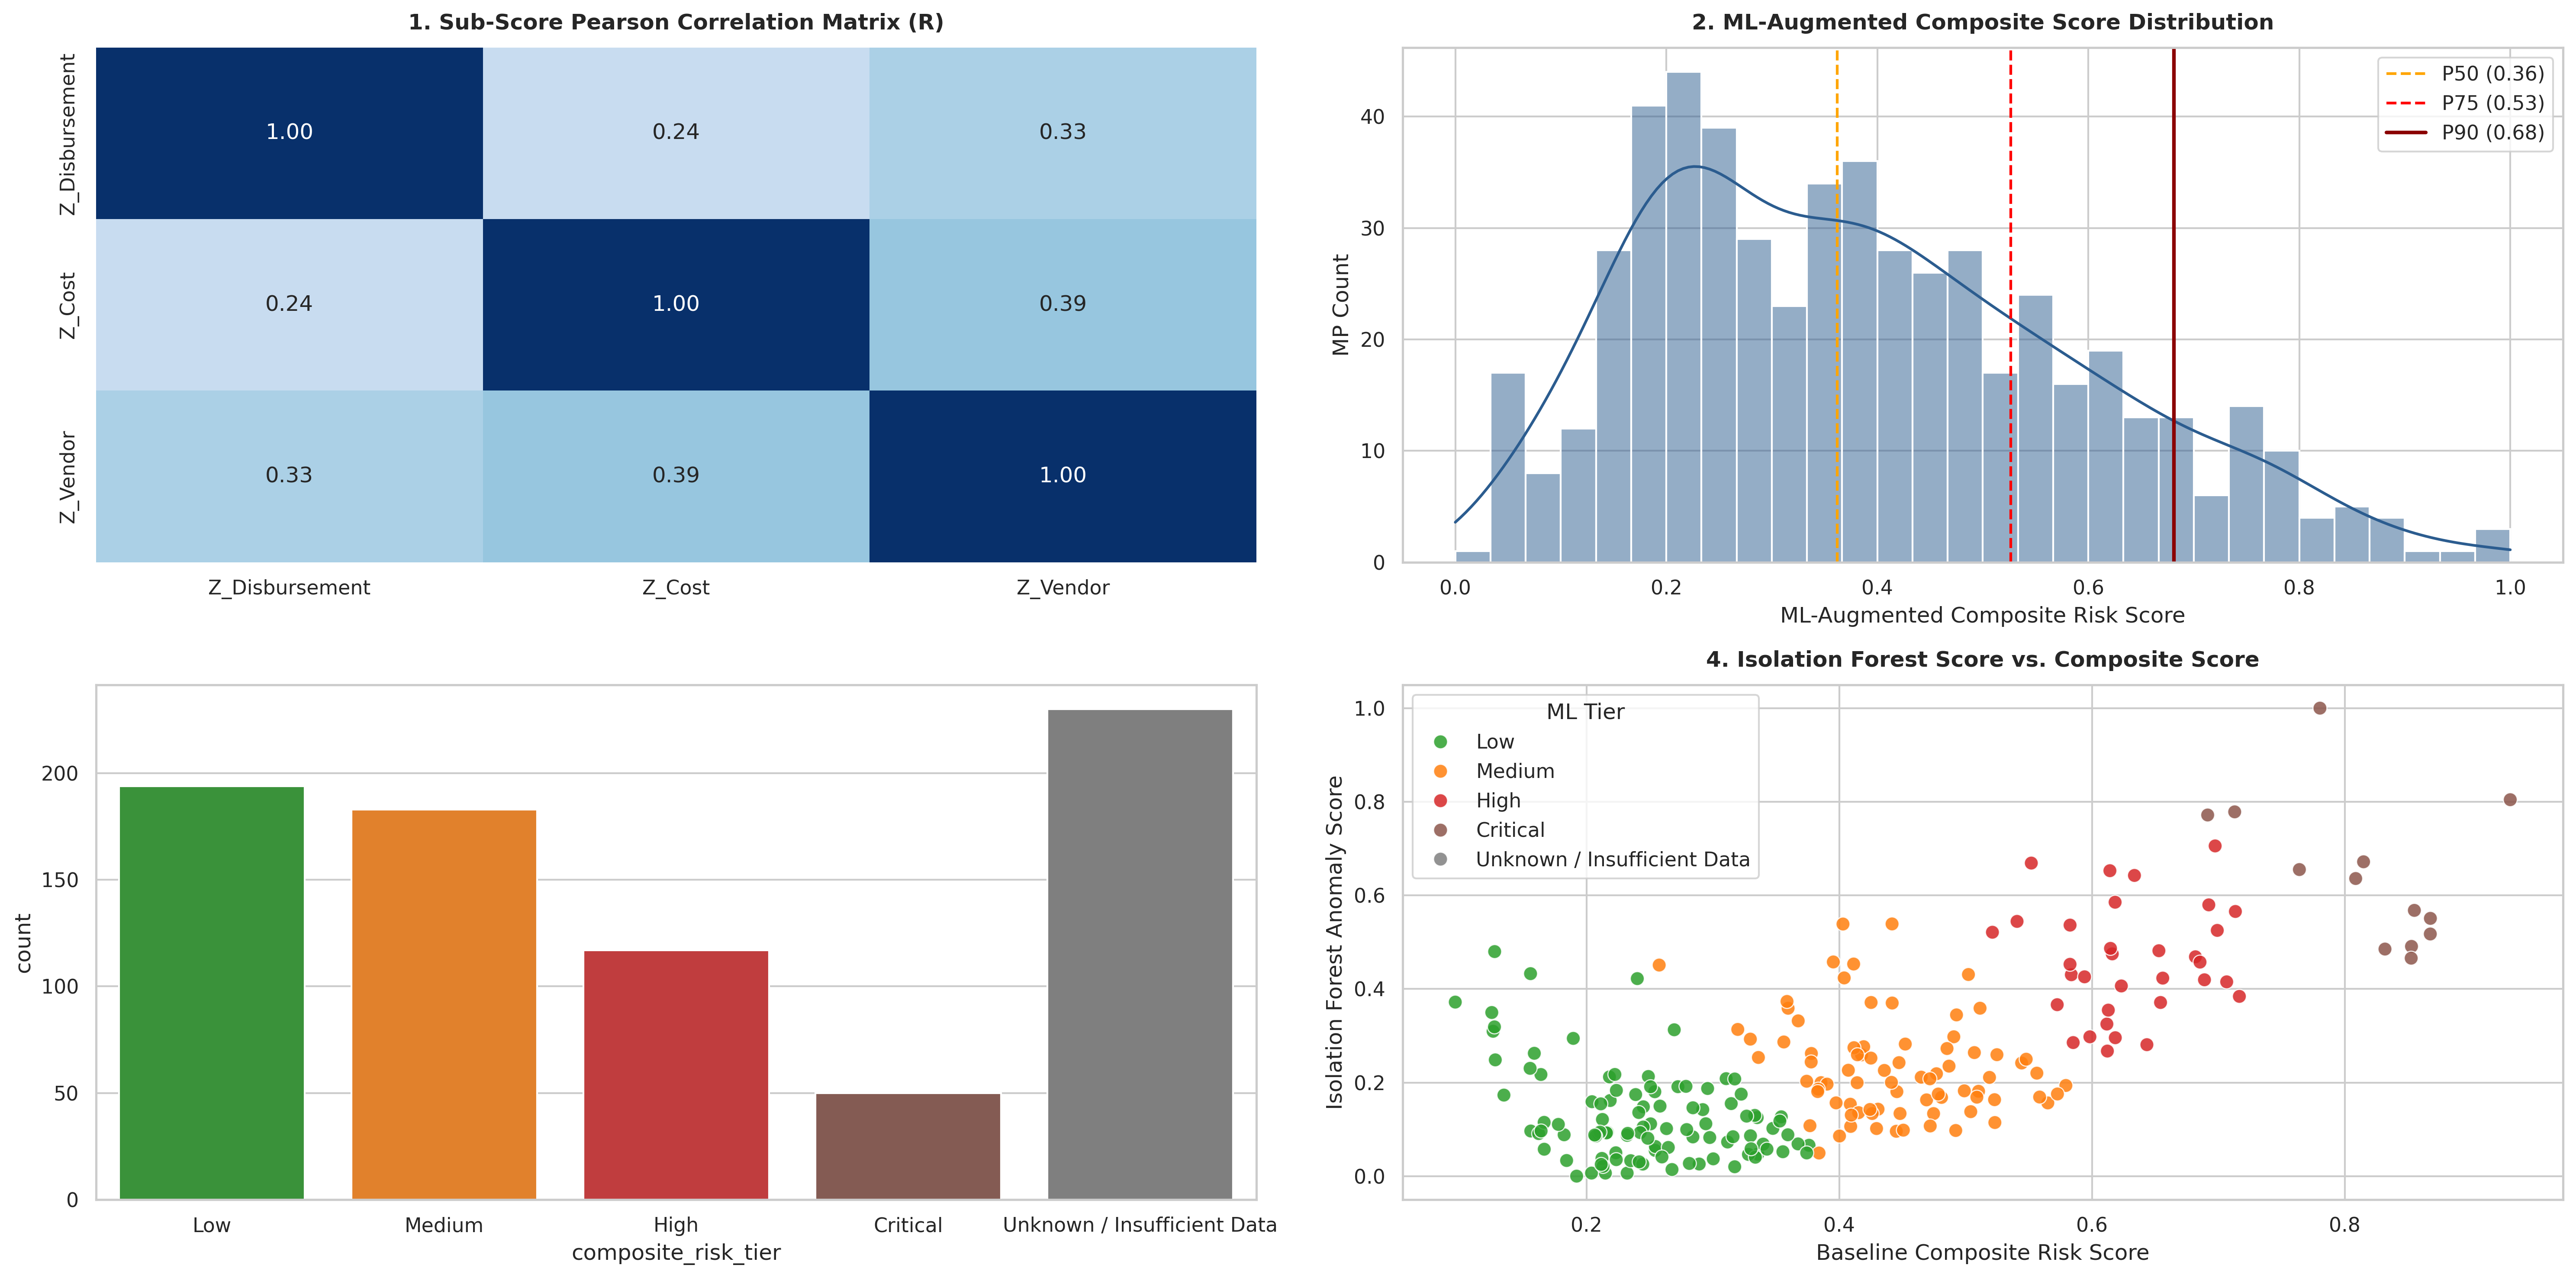

In [9]:
# Cell 9: Diagnostic Visualizations & 4-Panel Summary Figure
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 10), dpi=300)
sns.set_theme(style="whitegrid")

# Panel 1: Sub-Score Pearson Correlation Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", vmin=0, vmax=1.0, cbar=False,
            xticklabels=["Z_Disbursement", "Z_Cost", "Z_Vendor"],
            yticklabels=["Z_Disbursement", "Z_Cost", "Z_Vendor"])
plt.title("1. Sub-Score Pearson Correlation Matrix (R)", fontsize=12, fontweight="bold", pad=10)

# Panel 2: ML-Augmented Composite Risk Score Distribution
plt.subplot(2, 2, 2)
sns.histplot(mp_df["ml_augmented_composite_risk_score"], kde=True, color="#2b5c8f", bins=30)
# Diagnostic percentiles for plotting only. They do not define risk tiers.
valid_ml_scores = mp_df["ml_augmented_composite_risk_score"].dropna()
p50_ml, p75_ml, p90_ml = np.percentile(valid_ml_scores, [50, 75, 90])
plt.axvline(p50_ml, color="orange", linestyle="--", linewidth=1.5, label=f"P50 ({p50_ml:.2f})")
plt.axvline(p75_ml, color="red", linestyle="--", linewidth=1.5, label=f"P75 ({p75_ml:.2f})")
plt.axvline(p90_ml, color="darkred", linestyle="-", linewidth=2.0, label=f"P90 ({p90_ml:.2f})")
plt.title("2. ML-Augmented Composite Score Distribution", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("ML-Augmented Composite Risk Score")
plt.ylabel("MP Count")
plt.legend(loc="upper right")


# Panel 3: Baseline Percentile Risk Tier Breakdown
plt.subplot(2, 2, 3)
tier_order = ["Low", "Medium", "High", "Critical", "Unknown / Insufficient Data"]
palette = {
    "Low": "#2ca02c",
    "Medium": "#ff7f0e",
    "High": "#d62728",
    "Critical": "#8c564b",
    "Unknown / Insufficient Data": "#7f7f7f"
    }
sns.countplot(
    data=mp_df,
    x="composite_risk_tier",
    order=tier_order,
    palette=palette,
    hue="composite_risk_tier",
    legend=False
    )
# Panel 4: Isolation Forest Anomaly Score vs Composite Risk
plt.subplot(2, 2, 4)
sns.scatterplot(
    data=mp_df,
    x="composite_risk_score",
    y="mp_iforest_score",
    hue="ml_augmented_risk_tier",
    palette=palette,
    hue_order=tier_order,
    alpha=0.85,
    s=60
)
plt.title("4. Isolation Forest Score vs. Composite Score", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("Baseline Composite Risk Score")
plt.ylabel("Isolation Forest Anomaly Score")
plt.legend(title="ML Tier", loc="upper left")

plt.tight_layout()
plot_path = OUTPUT_DIR / "feature7_risk_distribution.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Saved 4-panel visualization figure to %s", plot_path)



In [10]:
display_cols = [
        "mp_key", "mp_name_clean", "house", "state", "constituency",
        "allocated_amount", "composite_risk_score", "mp_iforest_score",
        "ml_augmented_composite_risk_score", "ml_augmented_risk_tier",
        "mp_kmeans_tier", "composite_risk_explanation"
    ]

priority_mps = mp_df[mp_df["ml_augmented_risk_tier"].isin(["Critical", "High"])].sort_values(
    by="ml_augmented_composite_risk_score", ascending=False
)
print(f"Total High/Critical Priority MPs Identified (ML Augmented): {len(priority_mps)}")
print("--- Top 10 High/Critical Priority MP Risk Anomalies ---")

    # Safely filter display columns that exist in priority_mps
valid_cols = [c for c in display_cols if c in priority_mps.columns]
display_df = priority_mps[valid_cols].head(10)

try:
  from IPython.display import display
  display(display_df)
except Exception:
  print(display_df.to_string())


Total High/Critical Priority MPs Identified (ML Augmented): 150
--- Top 10 High/Critical Priority MP Risk Anomalies ---


,mp_key,mp_name_clean,house,state,constituency,allocated_amount,composite_risk_score,mp_iforest_score,ml_augmented_composite_risk_score,ml_augmented_risk_tier,mp_kmeans_tier,composite_risk_explanation
19,LS_ALFRED KANNGAM S ARTHUR,ALFRED KANNGAM S ARTHUR,LS,Manipur,OUTER MANIPUR(ST),147000000.0,1.000000,NaN,1.000000,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 1.00, Top 1..."
363,LS_RAJESH RANJAN ALIAS PAPPU YADAV,RAJESH RANJAN ALIAS PAPPU YADAV,LS,Bihar,PURNEA,147000000.0,1.000000,NaN,1.000000,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 1.00, Top 1..."
372,LS_RAKESH RATHOR,RAKESH RATHOR,LS,Uttar Pradesh,SITAPUR,147000000.0,1.000000,NaN,1.000000,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 1.00, Top 1..."
513,LS_THIRU DAYANIDHI MARAN,THIRU DAYANIDHI MARAN,LS,Tamil Nadu,CHENNAI CENTRAL,147000000.0,0.958886,NaN,0.958886,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.96, Top 1..."
312,LS_NISHIKANT DUBEY,NISHIKANT DUBEY,LS,Jharkhand,GODDA,147000000.0,0.901558,NaN,0.901558,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.90, Top 1..."
348,LS_R K CHAUDHARY,R K CHAUDHARY,LS,Uttar Pradesh,MOHANLALGANJ(SC),147000000.0,0.930970,0.804385,0.899324,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.90, Top 1..."
771,RS_SUDHA MURTY,SUDHA MURTY,RS,Karnataka,None,147000000.0,0.897520,NaN,0.897520,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.90, Top 1..."
233,LS_KAMLESH PASWAN,KAMLESH PASWAN,LS,Uttar Pradesh,BANSGAON(SC),147000000.0,0.881368,NaN,0.881368,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.88, Top 1..."
370,LS_RAJPALSINH MAHENDRASINH JADAV,RAJPALSINH MAHENDRASINH JADAV,LS,Gujarat,PANCHMAHAL,147000000.0,0.877694,NaN,0.877694,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.88, Top 1..."
321,LS_PARTHA BHOWMICK,PARTHA BHOWMICK,LS,West Bengal,BARRACKPUR,147000000.0,0.863831,NaN,0.863831,Critical,Critical,"CRITICAL COMPOSITE MP RISK (Score: 0.86, Top 1..."


In [11]:
# Export Artifacts & Data Bus Handoff
import json
from datetime import datetime

mp_export_cols = [
    "mp_key", "mp_name_clean", "house", "state", "state_key", "constituency",
    "allocated_amount", "total_sanctioned_amount", "allocation_utilization_pct", "z_s_f1", "z_s_f2", "z_s_f5", "s_f1", "s_f2", "s_f5", "f1_total_work_count", "f1_linked_work_count",
    "f1_coverage_rate", "f2_valid_cost_count", "f2_valid_cost_rate", "f5_vendor_risk_coverage", "s_f1_count_mean", "s_f2_count_mean", "s_f5_count_mean", "score_percentile",
    "composite_observed_dimension_count", "composite_data_quality_tier",
    "composite_risk_score", "composite_risk_tier", "mp_iforest_score",
    "ml_augmented_composite_risk_score", "ml_augmented_risk_tier",
    "composite_risk_explanation"
]
mp_scorecard = mp_df[[c for c in mp_export_cols if c in mp_df.columns]].sort_values(by="ml_augmented_composite_risk_score", ascending=False)
mp_parquet_path = OUTPUT_DIR / "feature7_mp_composite_risk.parquet"
mp_csv_path = OUTPUT_DIR / "feature7_mp_composite_risk.csv"
mp_scorecard.to_parquet(mp_parquet_path, index=False)
mp_scorecard.to_csv(mp_csv_path, index=False)

# Enriched fact_work_feature7
work_enriched = fact_work.merge(
    mp_scorecard[["mp_key", "ml_augmented_composite_risk_score", "ml_augmented_risk_tier"]].rename(
        columns={"ml_augmented_composite_risk_score": "mp_composite_risk_score", "ml_augmented_risk_tier": "mp_composite_risk_tier"}
    ),
    on="mp_key", how="left"
)

# ENSURE INCONSISTENCY #1 IS SOLVED: Unknown disbursement coverage rows stay NaN!
unknown_mask = work_enriched["coverage_flag"] == "disbursement_unknown"
work_enriched.loc[unknown_mask, "disbursement_risk_score"] = np.nan
work_enriched.loc[unknown_mask, "disbursement_risk_tier"] = "Unknown / Unlinked"

bus_parquet_path = SHARED_ARTIFACT_DIR / "fact_work_feature7.parquet"
bus_csv_path = SHARED_ARTIFACT_DIR / "fact_work_feature7.csv"
work_enriched.to_parquet(bus_parquet_path, index=False)
work_enriched.to_csv(bus_csv_path, index=False)

metadata = {
    "feature": "Feature 7 - Multi-Layer Risk Aggregation & MP Composite Scorecard",
    "created_at_utc": datetime.now().isoformat(),
    "threshold_version": "v2.0_calibrated",
    "threshold_source": "validation_partition_audit_capacity",
    "audit_capacity": {"critical_target_precision": 0.80, "high_target_precision": 0.60},
    "critical_threshold": CRITICAL_THRESH,
    "high_threshold": HIGH_THRESH,
    "medium_threshold": MEDIUM_THRESH,
    "mp_tier_counts": {str(k): int(v) for k, v in mp_df["ml_augmented_risk_tier"].value_counts().items()},
    "composite_data_quality_breakdown": {str(k): int(v) for k, v in mp_df["composite_data_quality_tier"].value_counts().items()},
    "ml_layer_complete_only": True,
    "score_percentile_is_diagnostic_only": True
}
with open(OUTPUT_DIR / "feature7_run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

logger.info("Successfully updated canonical work data bus table: %s", bus_parquet_path)


